In [19]:
import pandas as pd

In [20]:
df_platform_features = pd.read_csv("../results/platform_descriptors.csv", index_col=0)
df_radar_features = pd.read_csv("../results/radar_descriptors.csv", index_col=0)

Distance cosinus moyenne : 1.1872461031522714

Corrélation par composante PCA :
PC1   -0.980975
PC2    0.355230
PC3    0.882700
PC4    0.219294
PC5   -0.930484
dtype: float64

Corrélations CCA : [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9999999999999998), np.float64(nan)]


C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 4
  warnings.warn(f"y residual is constant at iteration {k}")
C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


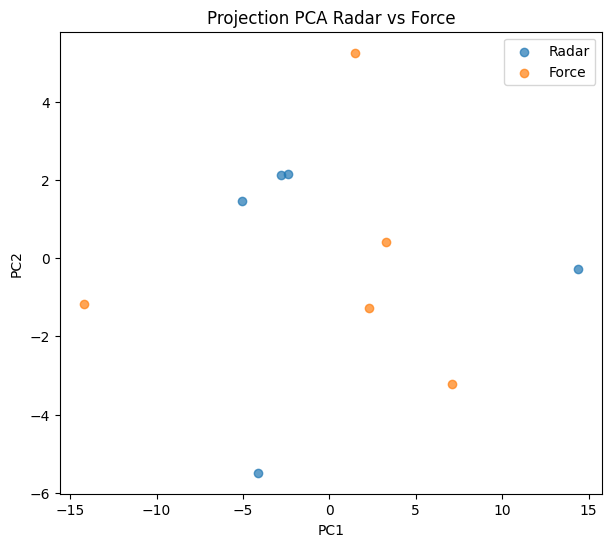

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from scipy.spatial.distance import cosine


scaler_radar = StandardScaler()
X_radar = scaler_radar.fit_transform(df_radar_features)

scaler_force = StandardScaler()
X_force = scaler_force.fit_transform(df_platform_features)


n_pca = 5  # tu peux ajuster
pca_radar = PCA(n_components=n_pca)
X_radar_pca = pca_radar.fit_transform(X_radar)

pca_force = PCA(n_components=n_pca)
X_force_pca = pca_force.fit_transform(X_force)


distances = [cosine(X_radar_pca[i], X_force_pca[i]) for i in range(len(X_radar_pca))]
print("Distance cosinus moyenne :", np.mean(distances))


df_radar_pca = pd.DataFrame(X_radar_pca, columns=[f'PC{i+1}' for i in range(n_pca)])
df_force_pca = pd.DataFrame(X_force_pca, columns=[f'PC{i+1}' for i in range(n_pca)])
corr_matrix = df_radar_pca.corrwith(df_force_pca, axis=0)
print("\nCorrélation par composante PCA :")
print(corr_matrix)


cca = CCA(n_components=n_pca)
X_radar_c, X_force_c = cca.fit_transform(X_radar, X_force)

cca_corrs = [np.corrcoef(X_radar_c[:,i], X_force_c[:,i])[0,1] for i in range(n_pca)]
print("\nCorrélations CCA :", cca_corrs)


plt.figure(figsize=(7,6))
plt.scatter(X_radar_pca[:,0], X_radar_pca[:,1], alpha=0.7, label='Radar')
plt.scatter(X_force_pca[:,0], X_force_pca[:,1], alpha=0.7, label='Force')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA Radar vs Force")
plt.legend()
plt.show()


In [22]:
import pingouin as pg

features = [col for col in df_platform_features.columns if col != 'type']

icc_results = {}

for feat in features:
    radar_vals = df_radar_features[feat].values
    force_vals = df_platform_features[feat].values
    
    # Créer DataFrame pour pingouin
    df_feat = pd.DataFrame({
        'Radar': radar_vals,
        'Force': force_vals
    })
    
    # Préparer pour pingouin
    df_tmp = df_feat.melt(var_name='Instrument', value_name='Score')
    df_tmp['Repetition'] = list(range(1, len(radar_vals)+1)) * 2  # répéter pour Radar et Force
    
    # Calculer ICC
    icc = pg.intraclass_corr(
        data=df_tmp,
        targets='Repetition',
        raters='Instrument',
        ratings='Score'
    )
    
    # Récupérer l'ICC de type "ICC2" (two-way, consistency, single) par exemple
    icc_value = icc.loc[icc['Type']=='ICC2','ICC'].values[0]
    icc_results[feat] = icc_value

# Convertir en DataFrame pour visualiser facilement
icc_df = pd.DataFrame.from_dict(icc_results, orient='index', columns=['ICC'])
icc_df = icc_df.sort_values('ICC', ascending=False)

print(icc_df)

                                                        ICC
energy_content_below_05_Power_Spectrum_Density_AP  0.865091
total_power_Power_Spectrum_Density_AP              0.859028
long_time_scaling_Diffusion_ML                     0.826198
mean_velocity_AP                                   0.825075
peak_velocity_all_SPD_AP                           0.794358
...                                                     ...
mean_distance_Radius                              -0.294352
mean_velocity_ML_AND_AP                           -0.429000
principal_sway_direction_ML_AND_AP                -0.595309
mean_distance_peak_Sway_Density                   -0.674343
sway_area_per_second_ML_AND_AP                    -0.745834

[72 rows x 1 columns]


In [24]:
icc_df
icc_df.to_csv("../results/icc.csv")